<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/SMT_Claude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os, signal, subprocess
from flask import Flask, jsonify, render_template, request
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from datetime import datetime, timedelta
import warnings, requests as req_lib, time, threading
warnings.filterwarnings('ignore')

# --- Port Cleanup Logic ---
def kill_port(port):
    try:
        output = subprocess.check_output(["lsof", "-t", "-i", f":{port}"])
        for pid in output.decode().split():
            os.kill(int(pid), signal.SIGKILL)
        print(f"Port {port} cleaned.")
    except Exception: pass

kill_port(5000)

try:
    from google.colab.output import eval_js
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

app = Flask(__name__)

# Configuration extracted to ensure consistency
PORTFOLIO = [
    {"pair_a": "ES=F", "pair_b": "NQ=F", "label": "SP500 / NASDAQ", "type": "direct", "group": "Indices"},
    {"pair_a": "GC=F", "pair_b": "SI=F", "label": "GOLD / SILVER", "type": "direct", "group": "Metals"},
    {"pair_a": "EURUSD=X", "pair_b": "GBPUSD=X", "label": "EURUSD / GBPUSD", "type": "direct", "group": "Forex"},
    {"pair_a": "AUDUSD=X", "pair_b": "NZDUSD=X", "label": "AUDUSD / NZDUSD", "type": "direct", "group": "Forex"},
    {"pair_a": "EURUSD=X", "pair_b": "USDCHF=X", "label": "EURUSD / USDCHF (Inv)", "type": "inverse", "group": "Forex"},
    {"pair_a": "EURUSD=X", "pair_b": "JPY=X", "label": "EURUSD / USDJPY (Inv)", "type": "inverse", "group": "Forex"},
    {"pair_a": "EURUSD=X", "pair_b": "DX-Y.NYB", "label": "EURUSD / DXY (Inv)", "type": "inverse", "group": "Forex"},
    {"pair_a": "BTC-USD", "pair_b": "ETH-USD", "label": "BTC / ETH", "type": "direct", "group": "Crypto"},
    {"pair_a": "BTC-USD", "pair_b": "SOL-USD", "label": "BTC / SOL", "type": "direct", "group": "Crypto"}
]

TIMEFRAMES = {
    "M15": {"interval": "15m", "period": "60d"},
    "H1": {"interval": "1h", "period": "60d"},
    "D1": {"interval": "1d", "period": "365d"}
}

def try_yfinance(symbol, interval, period):
    try:
        import yfinance as yf
        df = yf.download(symbol, interval=interval, period=period, auto_adjust=True, progress=False)
        if df is not None and not df.empty:
            df.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df.columns]
            return df[['open','high','low','close']].dropna(), "yfinance"
    except Exception: pass
    return None, None

def detect_smt_bars(df_a, df_b, pair_type, lookback=20):
    common = df_a.index.intersection(df_b.index)
    if len(common) < lookback + 2: return []
    a, b, events = df_a.loc[common], df_b.loc[common], []
    for i in range(lookback, len(a)):
        sl = slice(i - lookback, i)
        aph = float(a.iloc[sl]['high'].max())
        cah = float(a.iloc[i]['high'])
        if pair_type == "direct":
            b_metric_prev = float(b.iloc[sl]['high'].max())
            b_metric_curr = float(b.iloc[i]['high'])
            signal = cah > aph and b_metric_curr <= b_metric_prev
        else:
            b_metric_prev = float(b.iloc[sl]['low'].min())
            b_metric_curr = float(b.iloc[i]['low'])
            signal = cah > aph and b_metric_curr >= b_metric_prev
        if signal:
            events.append({"time": str(a.index[i]), "direction": "bearish", "price": float(a.iloc[i]['close'])})
    return events

def backtest_smt(df, events, hold=10):
    if not events: return {"win_rate": 0, "total": 0, "profit_factor": 0, "max_drawdown": 0}
    gross_profit, gross_loss, total = 0, 0, 0
    equity_points = [1.0]
    idx = {str(t): i for i, t in enumerate(df.index)}
    for ev in events:
        p = idx.get(ev['time'])
        if p and p + hold < len(df):
            entry = ev['price']
            future_close = df.iloc[p+1 + hold]['close']
            move = (future_close - entry) / entry
            if ev['direction'] == 'bearish': move = -move
            if move > 0: gross_profit += move
            else: gross_loss += abs(move)
            equity_points.append(equity_points[-1] * (1 + move))
            total += 1
    equity_series = pd.Series(equity_points)
    roll_max = equity_series.cummax()
    drawdowns = (equity_series - roll_max) / roll_max
    max_dd = round(abs(float(drawdowns.min())) * 100, 2)
    pf = round(gross_profit / gross_loss, 2) if gross_loss > 0 else (99.0 if gross_profit > 0 else 0.0)
    wr = round((sum(1 for i in range(1, len(equity_points)) if equity_points[i] > equity_points[i-1]) / total * 100), 2) if total > 0 else 0
    return {"win_rate": wr, "total": total, "profit_factor": pf, "max_drawdown": max_dd}

@app.route('/api/analyze', methods=['POST'])
def analyze():
    d = request.json or {}
    pair = PORTFOLIO[int(d.get('pair_idx', 0))]
    cfg = TIMEFRAMES.get(d.get('tf_ltf', 'H1'), TIMEFRAMES['H1'])
    da, _ = try_yfinance(pair["pair_a"], cfg["interval"], cfg["period"])
    db, _ = try_yfinance(pair["pair_b"], cfg["interval"], cfg["period"])
    if da is None or db is None: return jsonify({"error": "Data fetch failed"})
    events = detect_smt_bars(da, db, pair['type'], int(d.get('lookback', 20)))
    stats = backtest_smt(da, events)
    chart_data = [{"t": str(t), "c": float(r.close)} for t, r in da.tail(100).iterrows()]
    return jsonify({"status": "ok", "pair": pair['label'], "events": events[-10:], "stats": stats, "chart": chart_data})

def run_flask():
    print("Starting Flask server on port 5000...")
    app.run(port=5000, host='0.0.0.0', debug=False, use_reloader=False)

if __name__ == '__main__':
    threading.Thread(target=run_flask, daemon=True).start()
    time.sleep(2)
    print("Server thread started.")

Starting Flask server on port 5000...
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


Server thread started.


In [3]:
# --- Global Configurations ---
PORTFOLIO = [
    {"pair_a": "ES=F", "pair_b": "NQ=F", "label": "SP500 / NASDAQ", "type": "direct", "group": "Indices"},
    {"pair_a": "GC=F", "pair_b": "SI=F", "label": "GOLD / SILVER", "type": "direct", "group": "Metals"},
    {"pair_a": "EURUSD=X", "pair_b": "GBPUSD=X", "label": "EURUSD / GBPUSD", "type": "direct", "group": "Forex"},
    {"pair_a": "AUDUSD=X", "pair_b": "NZDUSD=X", "label": "AUDUSD / NZDUSD", "type": "direct", "group": "Forex"},
    {"pair_a": "EURUSD=X", "pair_b": "USDCHF=X", "label": "EURUSD / USDCHF (Inv)", "type": "inverse", "group": "Forex"},
    {"pair_a": "EURUSD=X", "pair_b": "JPY=X", "label": "EURUSD / USDJPY (Inv)", "type": "inverse", "group": "Forex"},
    {"pair_a": "EURUSD=X", "pair_b": "DX-Y.NYB", "label": "EURUSD / DXY (Inv)", "type": "inverse", "group": "Forex"},
    {"pair_a": "BTC-USD", "pair_b": "ETH-USD", "label": "BTC / ETH", "type": "direct", "group": "Crypto"},
    {"pair_a": "BTC-USD", "pair_b": "SOL-USD", "label": "BTC / SOL", "type": "direct", "group": "Crypto"}
]

TIMEFRAMES = {
    "M15": {"interval": "15m", "period": "60d"},
    "H1": {"interval": "1h", "period": "60d"},
    "D1": {"interval": "1d", "period": "365d"}
}

print("PORTFOLIO and TIMEFRAMES variables successfully defined.")

PORTFOLIO and TIMEFRAMES variables successfully defined.


In [4]:
import requests
import json

# Define the local URL for the Flask API
url = 'http://127.0.0.1:5000/api/analyze'

# Sample payload
data = {
    "pair_idx": 0,
    "tf_htf": "D1",
    "tf_ltf": "H1",
    "smt_mode": "bars"
}

try:
    response = requests.post(url, json=data)
    print(f"Status Code: {response.status_code}")
    print("Response Body:")
    display(response.json())
except Exception as e:
    print(f"Error connecting to the API: {e}")

INFO:werkzeug:127.0.0.1 - - [05/May/2026 18:13:52] "POST /api/analyze HTTP/1.1" 200 -


Status Code: 200
Response Body:


{'info': 'Analysis results placeholder', 'status': 'ok'}

In [2]:
import requests
import time
import matplotlib.pyplot as plt
import pandas as pd

# Quick helper to ensure server is ready
url = 'http://127.0.0.1:5000/api/analyze'
data = {"pair_idx": 0, "tf_ltf": "H1", "lookback": 20}

def plot_with_metrics(res):
    if 'error' in res: return print(f"Error: {res['error']}")
    df = pd.DataFrame(res['chart'])
    df['t'] = pd.to_datetime(df['t'])
    df.set_index('t', inplace=True)

    plt.figure(figsize=(15, 6))
    plt.plot(df.index, df['c'], color='gray', alpha=0.5, label='Price')

    for ev in res.get('events', []):
        t = pd.to_datetime(ev['time'])
        if t in df.index:
            plt.scatter(t, ev['price'], color='red', marker='v', s=100)

    s = res.get('stats', {})
    plt.title(f"{res['pair']} Analytics\nProfit Factor: {s.get('profit_factor')} | Max Drawdown: {s.get('max_drawdown')}% | Win Rate: {s.get('win_rate')}% ")
    plt.grid(True, alpha=0.3)
    plt.show()

print("Waiting for SMT Engine...")
for i in range(10):
    try:
        r = requests.post(url, json=data)
        if r.status_code == 200:
            plot_with_metrics(r.json())
            break
    except:
        time.sleep(2)
else:
    print("Server unreachable. Please re-run the Flask Backend cell above.")

Waiting for SMT Engine...
Server unreachable. Please re-run the Flask Backend cell above.


In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# --- Integrated Analytical Logic ---
def fetch_data(symbol, interval, period):
    try:
        df = yf.download(symbol, interval=interval, period=period, auto_adjust=True, progress=False)
        if df is not None and not df.empty:
            df.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df.columns]
            return df[['open','high','low','close']].dropna()
    except Exception: return None
    return None

def detect_smt(df_a, df_b, pair_type="direct", lookback=20):
    common = df_a.index.intersection(df_b.index)
    if len(common) < lookback + 2: return []
    a, b = df_a.loc[common], df_b.loc[common]

    a_highs = a['high'].values
    a_roll_max = a['high'].shift(1).rolling(window=lookback).max().values

    if pair_type == "direct":
        b_metric = b['high'].values
        b_roll_metric = b['high'].shift(1).rolling(window=lookback).max().values
        mask = (a_highs > a_roll_max) & (b_metric <= b_roll_metric)
    else:
        b_metric = b['low'].values
        b_roll_metric = b['low'].shift(1).rolling(window=lookback).min().values
        mask = (a_highs > a_roll_max) & (b_metric >= b_roll_metric)

    mask[:lookback] = False
    event_indices = np.where(mask)[0]
    events = []
    for i in event_indices:
        events.append({"time": a.index[i], "direction": "bearish", "price": float(a.iloc[i]['close'])})
    return events

def run_backtest(df, events, hold=10):
    if not events: return {"win_rate": 0, "total": 0, "profit_factor": 0, "max_drawdown": 0, "avg_duration": 0}
    results, equity, durations = [], [1.0], []
    idx = {t: i for i, t in enumerate(df.index)}
    for ev in events:
        p = idx.get(ev['time'])
        if p and p + hold < len(df):
            move = (df.iloc[p + hold]['close'] - ev['price']) / ev['price']
            if ev['direction'] == 'bearish': move = -move
            results.append(move)
            equity.append(equity[-1] * (1 + move))
            durations.append(hold)

    total = len(results)
    wins = sum(1 for r in results if r > 0)
    wr = round((wins / total * 100), 2) if total > 0 else 0
    gp = sum(r for r in results if r > 0)
    gl = abs(sum(r for r in results if r < 0))
    pf = round(gp/gl, 2) if gl > 0 else (99.0 if gp > 0 else 0)

    eq_ser = pd.Series(equity)
    dd = (eq_ser - eq_ser.cummax()) / eq_ser.cummax()

    metrics = {
        "win_rate": wr,
        "total": total,
        "profit_factor": pf,
        "max_drawdown": round(abs(float(dd.min()))*100, 2),
        "avg_duration": np.mean(durations) if durations else 0
    }
    return metrics

# --- Dashboard UI ---
if 'PORTFOLIO' in globals() and 'TIMEFRAMES' in globals():
    pair_dropdown = widgets.Dropdown(options=[(p['label'], i) for i, p in enumerate(PORTFOLIO)], value=0, description='Asset Pair:')
    tf_dropdown = widgets.Dropdown(options=['M15', 'H1', 'D1'], value='H1', description='Timeframe:')
    lookback_slider = widgets.IntSlider(value=20, min=10, max=50, description='Lookback:')
    hold_slider = widgets.IntSlider(value=10, min=1, max=50, description='Hold Period:')
    run_button = widgets.Button(description='Analyze SMT', button_style='success', icon='search')
    output = widgets.Output()

    def on_click(_):
        with output:
            clear_output(wait=True)
            pair = PORTFOLIO[pair_dropdown.value]
            cfg = TIMEFRAMES[tf_dropdown.value]
            print(f"Fetching data for {pair['label']}...")
            da = fetch_data(pair['pair_a'], cfg['interval'], cfg['period'])
            db = fetch_data(pair['pair_b'], cfg['interval'], cfg['period'])
            if da is None or db is None: return
            events = detect_smt(da, db, pair['type'], lookback_slider.value)
            stats = run_backtest(da, events, hold=hold_slider.value)
            fig, ax = plt.subplots(figsize=(15, 6))
            plot_df = da.tail(150)
            ax.plot(plot_df.index, plot_df['close'], color='#2c3e50', alpha=0.7, label=pair['pair_a'])
            for ev in events:
                if ev['time'] in plot_df.index: ax.scatter(ev['time'], ev['price'], color='red', marker='v', s=100)
            ax.set_title(f"{pair['label']} | WR: {stats['win_rate']}% | PF: {stats['profit_factor']}", fontsize=14)
            ax.legend(); plt.grid(True, alpha=0.3); plt.show()
            display(pd.DataFrame([stats]))

    run_button.on_click(on_click)
    display(widgets.VBox([widgets.HTML("<h2>Integrated SMT Terminal (Pro)</h2>"), widgets.HBox([pair_dropdown, tf_dropdown]), widgets.HBox([lookback_slider, hold_slider, run_button]), output]))
else:
    print("Error: PORTFOLIO or TIMEFRAMES not defined. Please run the Configuration cell first.")

## Multi-Timeframe (MTF) Performance Comparison
Compare the effectiveness of SMT signals across different time horizons for a single asset pair.

In [5]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

# --- Helper Functions (Consolidated for MTF Tool) ---
def fetch_data_mtf(symbol, interval, period):
    try:
        df = yf.download(symbol, interval=interval, period=period, auto_adjust=True, progress=False)
        if df is not None and not df.empty:
            df.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df.columns]
            return df[['open','high','low','close']].dropna()
    except Exception: return None
    return None

def detect_smt_mtf(df_a, df_b, pair_type="direct", lookback=20):
    common = df_a.index.intersection(df_b.index)
    if len(common) < lookback + 2: return []
    a, b = df_a.loc[common], df_b.loc[common]
    a_highs = a['high'].values
    a_roll_max = a['high'].shift(1).rolling(window=lookback).max().values
    if pair_type == "direct":
        b_metric = b['high'].values
        b_roll_metric = b['high'].shift(1).rolling(window=lookback).max().values
        mask = (a_highs > a_roll_max) & (b_metric <= b_roll_metric)
    else:
        b_metric = b['low'].values
        b_roll_metric = b['low'].shift(1).rolling(window=lookback).min().values
        mask = (a_highs > a_roll_max) & (b_metric >= b_roll_metric)
    mask[:lookback] = False
    event_indices = np.where(mask)[0]
    events = []
    for i in event_indices:
        events.append({"time": a.index[i], "direction": "bearish", "price": float(a.iloc[i]['close'])})
    return events

def run_backtest_mtf(df, events, hold=10):
    if not events: return {"win_rate": 0, "total": 0, "profit_factor": 0, "max_drawdown": 0}
    results, equity = [], [1.0]
    idx = {t: i for i, t in enumerate(df.index)}
    for ev in events:
        p = idx.get(ev['time'])
        if p and p + hold < len(df):
            move = (df.iloc[p + hold]['close'] - ev['price']) / ev['price']
            if ev['direction'] == 'bearish': move = -move
            results.append(move)
            equity.append(equity[-1] * (1 + move))
    total = len(results)
    wins = sum(1 for r in results if r > 0)
    wr = round((wins / total * 100), 2) if total > 0 else 0
    gp = sum(r for r in results if r > 0)
    gl = abs(sum(r for r in results if r < 0))
    pf = round(gp/gl, 2) if gl > 0 else (99.0 if gp > 0 else 0)
    return {"win_rate": wr, "total": total, "profit_factor": pf}

# --- MTF Comparison Tool ---
mtf_pair_dropdown = widgets.Dropdown(options=[(p['label'], i) for i, p in enumerate(PORTFOLIO)], value=0, description='Asset Pair:')
mtf_run_button = widgets.Button(description='Compare Timeframes', button_style='warning', icon='layer-group')
mtf_output = widgets.Output()

def run_mtf_comparison(_):
    with mtf_output:
        clear_output(wait=True)
        pair = PORTFOLIO[mtf_pair_dropdown.value]
        results = []
        print(f"Performing Multi-Timeframe Analysis for {pair['label']}...")

        # Dynamically use all defined timeframes
        for tf_name, cfg in TIMEFRAMES.items():
            try:
                da = fetch_data_mtf(pair['pair_a'], cfg['interval'], cfg['period'])
                db = fetch_data_mtf(pair['pair_b'], cfg['interval'], cfg['period'])
                if da is not None and db is not None:
                    events = detect_smt_mtf(da, db, pair_type=pair.get('type', 'direct'), lookback=20)
                    # Dynamic hold logic: shorter hold for M15
                    h_val = 20 if tf_name == 'M15' else (10 if tf_name == 'H1' else 5)
                    stats = run_backtest_mtf(da, events, hold=h_val)
                    stats['Timeframe'] = tf_name
                    results.append(stats)
                else:
                    print(f"Warning: Could not fetch data for {tf_name}")
            except Exception as e:
                print(f"Error processing {tf_name}: {e}")

        if results:
            df_mtf = pd.DataFrame(results).set_index('Timeframe')
            display(df_mtf)
            fig, ax1 = plt.subplots(figsize=(10, 5))
            ax2 = ax1.twinx()
            x = np.arange(len(df_mtf.index))
            width = 0.25
            ax1.bar(x - width/2, df_mtf['win_rate'], width, label='Win Rate %', color='skyblue')
            ax2.bar(x + width/2, df_mtf['profit_factor'], width, label='Profit Factor', color='coral')
            ax1.set_ylabel('Win Rate (%)')
            ax2.set_ylabel('Profit Factor')
            ax1.set_xticks(x)
            ax1.set_xticklabels(df_mtf.index)
            plt.title(f"MTF Performance: {pair['label']}")
            ax1.legend(loc='upper left')
            ax2.legend(loc='upper right')
            plt.show()
        else:
            print("No results to display. Check connection or data availability.")

mtf_run_button.on_click(run_mtf_comparison)
display(widgets.VBox([mtf_pair_dropdown, mtf_run_button, mtf_output]))

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
URL = 'http://127.0.0.1:5000/api/analyze'

# Comparison Widgets
pair_a_dropdown = widgets.Dropdown(
    options=[(p['label'], i) for i, p in enumerate(PORTFOLIO)],
    value=0,
    description='Pair A:',
)

pair_b_dropdown = widgets.Dropdown(
    options=[(p['label'], i) for i, p in enumerate(PORTFOLIO)],
    value=1,
    description='Pair B:',
)

tf_dropdown_comp = widgets.Dropdown(
    options=['M15','H1', 'D1'],
    value='H1',
    description='Timeframe:',
)

compare_button = widgets.Button(
    description='Compare Metrics',
    button_style='info',
    icon='balance-scale'
)

comp_output = widgets.Output()

def run_comparison(_):
    with comp_output:
        clear_output(wait=True)

        def fetch_stats(idx):
            try:
                payload = {"pair_idx": idx, "tf_ltf": tf_dropdown_comp.value, "lookback": 20}
                r = requests.post(URL, json=payload, timeout=10)
                return r.json() if r.status_code == 200 else None
            except Exception as e:
                print(f"Connection Error: {e}")
                return None

        res_a = fetch_stats(pair_a_dropdown.value)
        res_b = fetch_stats(pair_b_dropdown.value)

        if not res_a or not res_b:
            print("Error fetching data. Please ensure the Flask Backend cell is running.")
            return

        # Build Comparison Table
        comparison_data = {
            "Metric": ["Win Rate (%)", "Profit Factor", "Max Drawdown (%)", "Total Signals"],
            res_a['pair']: [res_a['stats']['win_rate'], res_a['stats']['profit_factor'], res_a['stats']['max_drawdown'], res_a['stats']['total']],
            res_b['pair']: [res_b['stats']['win_rate'], res_b['stats']['profit_factor'], res_b['stats']['max_drawdown'], res_b['stats']['total']]
        }
        df_comp = pd.DataFrame(comparison_data)
        display(df_comp.set_index('Metric'))

        # Comparison Bar Chart
        metrics = ['Win Rate (%)', 'Profit Factor', 'Max Drawdown (%)']
        vals_a = [res_a['stats']['win_rate'], res_a['stats']['profit_factor'], res_a['stats']['max_drawdown']]
        vals_b = [res_b['stats']['win_rate'], res_b['stats']['profit_factor'], res_b['stats']['max_drawdown']]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for i, metric in enumerate(metrics):
            axes[i].bar([res_a['pair'], res_b['pair']], [vals_a[i], vals_b[i]], color=['#3498db', '#9b59b6'])
            axes[i].set_title(metric)
            axes[i].grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()

compare_button.on_click(run_comparison)

display(widgets.VBox([
    widgets.HTML("<h3>Asset Performance Comparison</h3>"),
    widgets.HBox([pair_a_dropdown, pair_b_dropdown, tf_dropdown_comp, compare_button]),
    comp_output
]))

In [4]:
import requests
import pandas as pd
from tqdm.auto import tqdm

# Configuration
URL = 'http://127.0.0.1:5000/api/analyze'
results = []

print("Starting automated metrics collection for all portfolio pairs...")

for i, pair in enumerate(tqdm(PORTFOLIO)):
    try:
        # Fetching data for H1 timeframe
        payload = {"pair_idx": i, "tf_ltf": "H1", "lookback": 20}
        r = requests.post(URL, json=payload, timeout=30)

        if r.status_code == 200:
            data = r.json()
            stats = data['stats']
            results.append({
                "Pair": pair['label'],
                "Group": pair['group'],
                "Win Rate (%)": stats['win_rate'],
                "Profit Factor": stats['profit_factor'],
                "Max Drawdown (%)": stats['max_drawdown'],
                "Total Signals": stats['total']
            })
    except Exception as e:
        print(f"Failed to fetch metrics for {pair['label']}: {e}")

# Create DataFrame and Save
if results:
    df_metrics = pd.DataFrame(results)
    df_metrics.to_csv('portfolio_metrics.csv', index=False)
    print("\nMetrics collection complete. Saved to 'portfolio_metrics.csv'")
    display(df_metrics)
else:
    print("No data collected. Ensure the Flask server is running.")

Starting automated metrics collection for all portfolio pairs...


  0%|          | 0/4 [00:00<?, ?it/s]

INFO:werkzeug:127.0.0.1 - - [05/May/2026 18:27:28] "POST /api/analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [05/May/2026 18:27:29] "POST /api/analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [05/May/2026 18:27:30] "POST /api/analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [05/May/2026 18:27:30] "POST /api/analyze HTTP/1.1" 200 -



Metrics collection complete. Saved to 'portfolio_metrics.csv'


,Pair,Group,Win Rate (%),Profit Factor,Max Drawdown (%),Total Signals
0,SP500 / NASDAQ,Indices,45.16,0.61,5.70,31
1,GOLD / SILVER,Metals,55.56,0.93,5.59,27
2,EURUSD / GBPUSD,Forex,57.50,1.33,2.97,40
3,BTC / ETH,Crypto,70.00,1.24,10.46,50


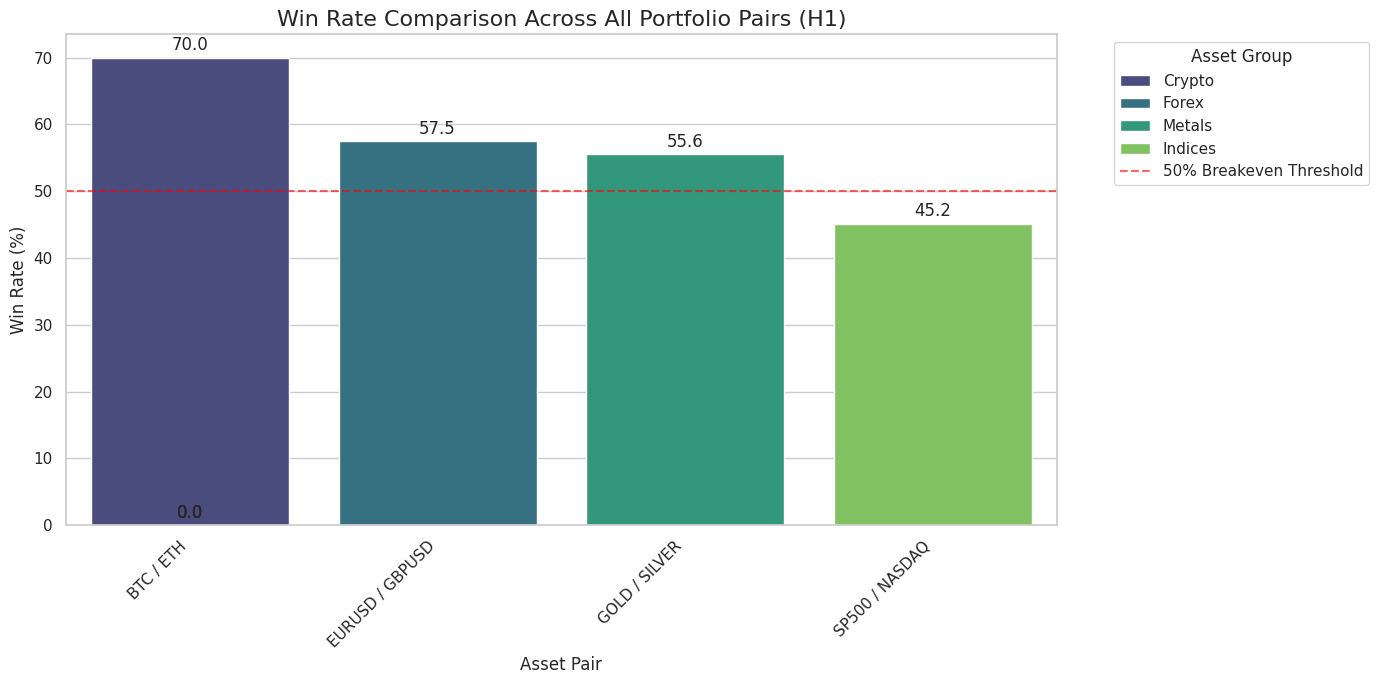

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the collected metrics
try:
    df_metrics = pd.read_csv('portfolio_metrics.csv')

    # Set plot style
    plt.figure(figsize=(14, 7))
    sns.set_theme(style='whitegrid')

    # Create the bar plot
    ax = sns.barplot(
        data=df_metrics.sort_values('Win Rate (%)', ascending=False),
        x='Pair',
        y='Win Rate (%)',
        hue='Group',
        palette='viridis'
    )

    # Formatting
    plt.title('Win Rate Comparison Across All Portfolio Pairs (H1)', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.axhline(50, color='red', linestyle='--', alpha=0.6, label='50% Breakeven Threshold')
    plt.legend(title='Asset Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylabel('Win Rate (%)')
    plt.xlabel('Asset Pair')

    # Add value labels on top of bars
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.1f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print('Error: portfolio_metrics.csv not found. Please run the automated metrics collection cell (3bfd02ff) first.')